In [ ]:
#install dependencies
!pip install openai seqeval -q
!pip install matplotlib
print('✅ Dependencies installed')

✅ Dependencies installed


In [ ]:
#imports and configuration
import json, time, pickle, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from seqeval.metrics import (
    f1_score, precision_score, recall_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

LABELS = ['O', 'B-SYM', 'I-SYM', 'B-DGN', 'I-DGN',
          'B-TMP', 'I-TMP', 'B-RF', 'I-RF']

print('Ready')

✅ Ready


In [ ]:
#Load data
import os
try:
    from google.colab import files
    print('Upload train_fixed.tsv, val_fixed.tsv, test_fixed.tsv:')
    uploaded = files.upload()
except ImportError:
    print('google.colab.files not available. Assuming files are in current directory.')
    uploaded = {}
    for filename in ['train_fixed.tsv', 'val_fixed.tsv', 'test_fixed.tsv']:
        if os.path.exists(filename):
            with open(filename, 'rb') as f:
                uploaded[filename] = f.read()
        else:
            print(f"Warning: {filename} not found locally. This may cause subsequent errors.")

def load_tsv(byte_content):
    """Parse CoNLL-style BIO TSV. Returns list of (tokens, labels) tuples."""
    sentences = []
    toks, labs = [], []
    for line in byte_content.decode('utf-8').splitlines():
        line = line.strip()
        if line == '':
            if toks:
                sentences.append((toks, labs))
            toks, labs = [], []
        else:
            parts = line.split('\t')
            if len(parts) == 2:
                toks.append(parts[0])
                labs.append(parts[1])
    if toks:
        sentences.append((toks, labs))
    return sentences

train_data = load_tsv(uploaded.get('train_fixed.tsv', b''))
val_data   = load_tsv(uploaded.get('val_fixed.tsv', b''))
test_data  = load_tsv(uploaded.get('test_fixed.tsv', b''))

print(f'\nLoaded — Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

#Sanity check: label set
all_labels_found = set()
for sents in [train_data, val_data, test_data]:
    for _, labs in sents:
        all_labels_found.update(labs)
unexpected = all_labels_found - set(LABELS)
print(f'Unexpected labels: {unexpected if unexpected else "None"}')


google.colab.files not available. Assuming files are in current directory.

Loaded — Train: 1211 | Val: 256 | Test: 275
Unexpected labels: None ✅


In [ ]:
#Fine-tuned model results
all_results = {
    'IndoBERT-base + Linear': {
        'model': 'IndoBERT-base+Linear',
        'overall':    {'f1': 0.7367, 'prec': 0.6976, 'rec': 0.7818},
        'per_entity': {
            'DGN': {'f1': 0.8779, 'prec': 0.8363, 'rec': 0.9237},
            'RF':  {'f1': 0.7326, 'prec': 0.7194, 'rec': 0.7463},
            'SYM': {'f1': 0.6681, 'prec': 0.6230, 'rec': 0.7202},
            'TMP': {'f1': 0.6684, 'prec': 0.6117, 'rec': 0.7368},
        }
    },
    'IndoBERT-base + CRF': {
        'model': 'IndoBERT-base+CRF',
        'overall':    {'f1': 0.7427, 'prec': 0.7017, 'rec': 0.7896},
        'per_entity': {
            'DGN': {'f1': 0.8564, 'prec': 0.8090, 'rec': 0.9096},
            'RF':  {'f1': 0.7273, 'prec': 0.7092, 'rec': 0.7463},
            'SYM': {'f1': 0.6759, 'prec': 0.6333, 'rec': 0.7248},
            'TMP': {'f1': 0.7112, 'prec': 0.6552, 'rec': 0.7778},
        }
    },
    'IndoBERT-large + Linear': {
        'model': 'IndoBERT-large+Linear',
        'overall':    {'f1': 0.7614, 'prec': 0.7264, 'rec': 0.8004},
        'per_entity': {
            'DGN': {'f1': 0.8925, 'prec': 0.8609, 'rec': 0.9266},
            'RF':  {'f1': 0.7626, 'prec': 0.7361, 'rec': 0.7910},
            'SYM': {'f1': 0.6842, 'prec': 0.6534, 'rec': 0.7179},
            'TMP': {'f1': 0.7062, 'prec': 0.6550, 'rec': 0.7661},
        }
    },
    'XLM-RoBERTa + Linear': {
        'model': 'XLM-RoBERTa-large+Linear',
        'overall':    {'f1': 0.7735, 'prec': 0.7394, 'rec': 0.8125},
        'per_entity': {
            'DGN': {'f1': 0.8693, 'prec': 0.8232, 'rec': 0.9209},
            'RF':  {'f1': 0.7761, 'prec': 0.7704, 'rec': 0.7820},
            'SYM': {'f1': 0.7164, 'prec': 0.6940, 'rec': 0.7402},
            'TMP': {'f1': 0.7321, 'prec': 0.6699, 'rec': 0.8070},
        }
    },
}

print(f'Loaded {len(all_results)} fine-tuned model results:')
for name, r in all_results.items():
    print(f'  {name}: F1={r["overall"]["f1"]:.4f}')


Loaded 4 fine-tuned model results:
  IndoBERT-base + Linear: F1=0.7367
  IndoBERT-base + CRF: F1=0.7427
  IndoBERT-large + Linear: F1=0.7614
  XLM-RoBERTa + Linear: F1=0.7735


In [ ]:
#DIAGNOSTIC
import openai

#openai library version
ver = tuple(int(x) for x in openai.__version__.split('.')[:2])
if ver >= (1, 0):
    print('openai version:', openai.__version__, '(v1.x client API supported)')
else:
    print('openai version:', openai.__version__, '— too old')
    print('   Run: !pip install openai --upgrade -q')

#API key
OPENAI_API_KEY = ''   # ← paste your real key here

if OPENAI_API_KEY.startswith('sk-...') or len(OPENAI_API_KEY) < 20:
    print('API key: still showing placeholder — paste your real key above')
else:
    print('API key: set (starts with', OPENAI_API_KEY[:8], '...)')

#list available models on your account
from openai import OpenAI
client = OpenAI(api_key=OPENAI_API_KEY)

try:
    models = client.models.list()
    gpt_models = sorted(
        [m.id for m in models.data if 'gpt-5' in m.id or 'gpt-4' in m.id],
        reverse=True
    )
    if gpt_models:
        print('\nGPT models available on your account:')
        for m in gpt_models[:15]:
            print('   ->', m)
        print('\n   Copy the exact string you want into GPT_MODEL in Cell 6.')
    else:
        print('\n No GPT-4/5 models found on your account.')
        print('   Check: https://platform.openai.com/docs/models')
except Exception as e:
    err = str(e)
    if '401' in err or 'Unauthorized' in err or 'invalid_api_key' in err:
        print('Authentication failed — API key is invalid or expired')
        print('   Go to: https://platform.openai.com/api-keys')
    elif '403' in err or 'Permission' in err:
        print('Permission denied — check billing at platform.openai.com/account/billing')
    elif '429' in err:
        print('Rate limited — check usage at platform.openai.com/usage')
    else:
        print('Unexpected error:', err)


✅ openai version: 2.36.0 (v1.x client API supported)
✅ API key: set (starts with sk-proj- ...)

✅ GPT models available on your account:
   -> gpt-5.5-pro-2026-04-23
   -> gpt-5.5-pro
   -> gpt-5.5-2026-04-23
   -> gpt-5.5
   -> gpt-5.4-pro-2026-03-05
   -> gpt-5.4-pro
   -> gpt-5.4-nano-2026-03-17
   -> gpt-5.4-nano
   -> gpt-5.4-mini-2026-03-17
   -> gpt-5.4-mini
   -> gpt-5.4-2026-03-05
   -> gpt-5.4
   -> gpt-5.3-codex
   -> gpt-5.3-chat-latest
   -> gpt-5.2-pro-2025-12-11

   Copy the exact string you want into GPT_MODEL in Cell 6.


In [ ]:
#GPT-5.4 Zero-Shot NER
from openai import OpenAI

OPENAI_API_KEY = ''     # ← Paste your OpenAI API key here
GPT_MODEL      = 'gpt-5.4'

client = OpenAI(api_key=OPENAI_API_KEY)

#System prompt
SYSTEM_PROMPT = """You are a clinical Named Entity Recognition (NER) system for Indonesian stroke patient queries.

Label each token with one of these BIO tags:
  B-SYM / I-SYM : Symptoms or functional deficits reported as a consequence of stroke
                  (e.g., lemas, kesemutan, tidak bisa bicara, mulut miring, afasia)
  B-DGN / I-DGN : Stroke diagnosis or lay description of stroke pathology
                  (e.g., stroke, stroke ringan, pendarahan di otak, penyumbatan di otak)
  B-TMP / I-TMP : Temporal expressions — when symptoms started or how long they lasted
                  (e.g., tiba-tiba, sudah 3 hari, sejak kemarin, mendadak)
  B-RF  / I-RF  : Risk factors — pre-existing conditions, age, lifestyle, or trauma
                  (e.g., hipertensi, diabetes, usia 65 tahun, kolesterol, kecelakaan)
  O             : Not an entity

Key annotation rules:
1. Stroke spelling variants are ALL B-DGN: struk, strok, storke, stoke, setruk, sroke
2. Age is B-RF and must include the full phrase: 'usia 65 tahun' — all three tokens are RF
3. Negated symptoms (e.g., 'tidak bisa bicara') — SYM (functional deficit even if negated)
4. Negated risk factors (e.g., 'tidak ada hipertensi') — O (condition is absent)
5. Numeric blood pressure values (190/100) — O; label the condition name (hipertensi) as RF
6. Body parts alone (tangan, kaki) — O; only label clinical expressions (mulut miring) as SYM
7. Recovery descriptions (sudah membaik, tidak kunjung sembuh) — O, not SYM
8. Medical procedures (CT scan, MRI, USG) — O
9. 'bangun tidur' (woke from sleep) — O, not TMP
10. 'sudah' + duration (sudah 3 hari) — TMP; 'sudah' + recovery description — O

CRITICAL output requirement:
Return ONLY a JSON array with exactly one object per input token, in the same order:
[{"token": "...", "label": "..."}, ...]
The number of objects MUST equal the number of input tokens.
Do NOT merge tokens. Do NOT split tokens. Do NOT skip tokens.
No markdown, no explanation — only the raw JSON array."""


def align_gpt_to_input(input_tokens, gpt_items):
    """
    Align GPT token-label pairs back to the original input token list.

    GPT sometimes merges multiple input tokens into one item (e.g. 'tidak bisa bicara'),
    splits one input token into multiple items (e.g. 'tiba-tiba' -> ['tiba','-','tiba']),
    or skips punctuation. This function recovers correct labels for all input tokens
    even when counts don't match, instead of discarding all labels.
    """
    result  = ['O'] * len(input_tokens)
    inp_idx = 0

    def try_merge_from(pos):
        """Check if gpt_tok matches a merge of input tokens starting at pos."""
        consumed = ''
        j = pos
        while j < len(input_tokens) and len(consumed) <= len(gpt_tok) + 5:
            consumed = (consumed + ' ' + input_tokens[j]).strip()
            if consumed.lower() == gpt_tok.lower():
                return j
            if len(consumed) > len(gpt_tok) + 2:
                break
            j += 1
        return None

    for item in gpt_items:
        if inp_idx >= len(input_tokens):
            break
        gpt_tok = item.get('token', '').strip()
        gpt_lab = item.get('label', 'O')
        if gpt_lab not in LABELS:
            gpt_lab = 'O'
        if not gpt_tok:
            continue

        def assign_merge(start, end, lab):
            """Assign lab to start, and the continuation tag to start+1..end."""
            for k in range(start, end + 1):
                if k == start:
                    result[k] = lab
                else:
                    result[k] = ('I-' + lab[2:]) if lab.startswith('B-') else lab

        #Try at current position
        if gpt_tok.lower() == input_tokens[inp_idx].lower():
            result[inp_idx] = gpt_lab
            inp_idx += 1
            continue

        merge_end = try_merge_from(inp_idx)
        if merge_end is not None:
            assign_merge(inp_idx, merge_end, gpt_lab)
            inp_idx = merge_end + 1
            continue

        if (len(gpt_tok) < len(input_tokens[inp_idx]) and
                gpt_tok.lower() in input_tokens[inp_idx].lower()):
            result[inp_idx] = gpt_lab
            inp_idx += 1
            continue

        #GPT skipped input tokens — look ahead up to 3 positions ─
        for lookahead in range(1, 4):
            ahead = inp_idx + lookahead
            if ahead >= len(input_tokens):
                break
            if gpt_tok.lower() == input_tokens[ahead].lower():
                inp_idx = ahead
                result[inp_idx] = gpt_lab
                inp_idx += 1
                break
            merge_end = try_merge_from(ahead)
            if merge_end is not None:
                inp_idx = ahead
                assign_merge(inp_idx, merge_end, gpt_lab)
                inp_idx = merge_end + 1
                break
            if (len(gpt_tok) < len(input_tokens[ahead]) and
                    gpt_tok.lower() in input_tokens[ahead].lower()):
                inp_idx = ahead
                result[inp_idx] = gpt_lab
                inp_idx += 1
                break
        # If still unmatched: GPT hallucinated a token — skip it silently

    return result


def gpt_ner(tokens, max_retries=5):
    """
    Call GPT-5.4 to label a token sequence with BIO NER tags.
    Uses exponential backoff on rate limit errors.
    Uses align_gpt_to_input() to recover labels when token counts mismatch.
    Falls back to all-O labeling only if the response is completely unparseable.
    """
    text = ' '.join(tokens)
    wait = 2

    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=GPT_MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': text}
                ],
                temperature=0,
                max_completion_tokens=4096
            )
            raw = resp.choices[0].message.content.strip()
            raw = raw.replace('```json', '').replace('```', '').strip()
            result = json.loads(raw)

            if len(result) == len(tokens):
                # Perfect match — use directly
                labels = [item.get('label', 'O') for item in result]
                return [l if l in LABELS else 'O' for l in labels]
            else:
                # Mismatch — use alignment recovery instead of all-O fallback
                return align_gpt_to_input(tokens, result)

        except Exception as e:
            err = str(e)
            if 'rate_limit' in err.lower() or '429' in err:
                print(f'  Rate limit (attempt {attempt+1}/{max_retries}) — waiting {wait}s...')
                time.sleep(wait)
                wait = min(wait * 2, 60)
            elif attempt < max_retries - 1:
                time.sleep(wait)
            else:
                print(f'  Failed after {max_retries} attempts: {err[:80]}')
                return ['O'] * len(tokens)

    return ['O'] * len(tokens)


#Run inference
print(f'Model:     {GPT_MODEL}')
print(f'Sentences: {len(test_data)}')
print(f'Est. cost: ~$3-10 USD (GPT-5.4 flagship — check your tier)')
print(f'Est. time: 15–25 minutes')
print()

gpt_preds = []
gpt_golds = []
mismatch_count = 0

for i, (tokens, labels) in enumerate(test_data):
    pred = gpt_ner(tokens)
    if len(pred) != len(tokens):
        mismatch_count += 1  # should never happen now
    gpt_preds.append(pred)
    gpt_golds.append(labels)
    time.sleep(0.5)

    if (i + 1) % 25 == 0:
        running_f1 = f1_score(gpt_golds, gpt_preds, average='macro', zero_division=0)
        print(f'  {i+1}/{len(test_data)} | Running macro F1: {running_f1:.4f}')

print(f'\nToken count mismatches after alignment: {mismatch_count} (should be 0)')

#Evaluate
gpt_f1   = f1_score(gpt_golds,        gpt_preds, average='macro', zero_division=0)
gpt_prec = precision_score(gpt_golds,  gpt_preds, average='macro', zero_division=0)
gpt_rec  = recall_score(gpt_golds,    gpt_preds, average='macro', zero_division=0)

print(f'GPT-5.4 Zero-Shot: F1={gpt_f1:.4f}  P={gpt_prec:.4f}  R={gpt_rec:.4f}')
print(classification_report(gpt_golds, gpt_preds, zero_division=0))

report_gpt = classification_report(gpt_golds, gpt_preds, output_dict=True, zero_division=0)
per_gpt = {
    e: {
        'prec': report_gpt.get(e, {}).get('precision', 0),
        'rec':  report_gpt.get(e, {}).get('recall',    0),
        'f1':   report_gpt.get(e, {}).get('f1-score',  0)
    }
    for e in ['DGN', 'RF', 'SYM', 'TMP']
}

GPT_KEY = 'GPT-5.4 (zero-shot)'
all_results[GPT_KEY] = {
    'model':      GPT_KEY,
    'overall':    {'f1': gpt_f1, 'prec': gpt_prec, 'rec': gpt_rec},
    'per_entity': per_gpt
}

Model:     gpt-5.4
Sentences: 275
Est. cost: ~$3-10 USD (GPT-5.4 flagship — check your tier)
Est. time: 15–25 minutes

  25/275 | Running macro F1: 0.5681
  50/275 | Running macro F1: 0.5534
  Failed after 5 attempts: Expecting ':' delimiter: line 1 column 494 (char 493)
  75/275 | Running macro F1: 0.5403
  100/275 | Running macro F1: 0.5334
  Failed after 5 attempts: Expecting ':' delimiter: line 1 column 336 (char 335)
  125/275 | Running macro F1: 0.5484
  150/275 | Running macro F1: 0.6747
  175/275 | Running macro F1: 0.6711
  200/275 | Running macro F1: 0.6817
  225/275 | Running macro F1: 0.6776
  250/275 | Running macro F1: 0.6727
  275/275 | Running macro F1: 0.6682

Token count mismatches after alignment: 0 (should be 0)

GPT-5.4 Zero-Shot: F1=0.6682  P=0.6762  R=0.6659
              precision    recall  f1-score   support

         DGN       0.85      0.91      0.88       354
          RF       0.60      0.51      0.55       134
         SYM       0.60      0.51      0.55  

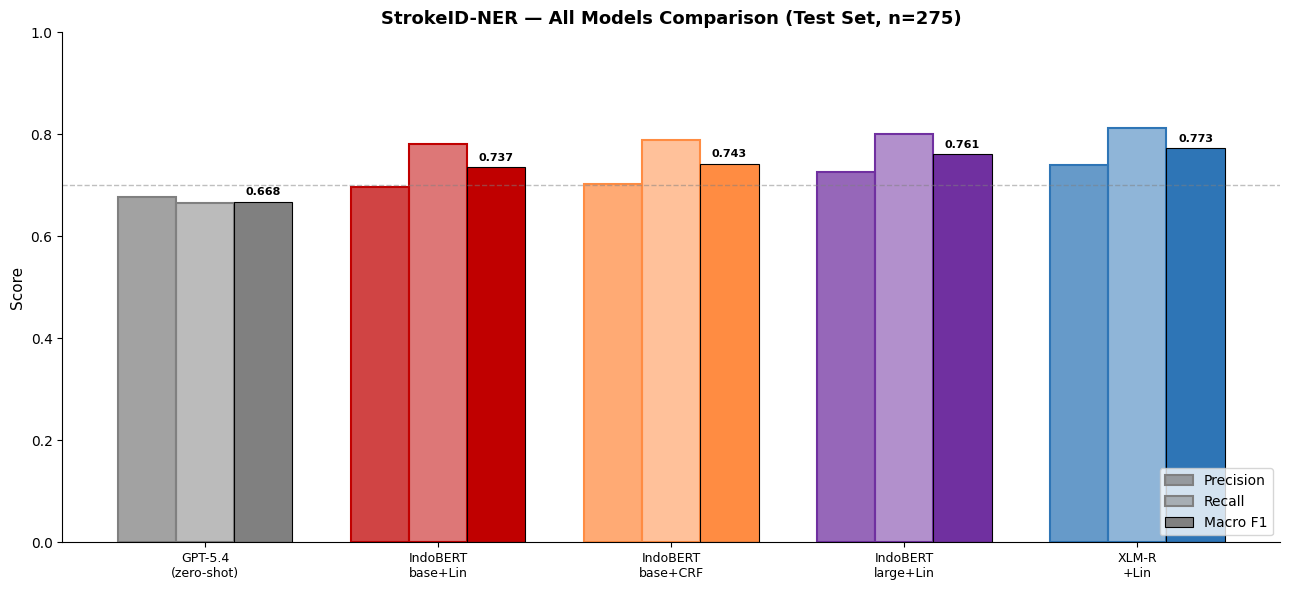

✅ Saved: all_models_comparison.png


In [ ]:
#figure 1 All Models Comparison
MODELS_ORDER = [
    'GPT-5.4 (zero-shot)',
    'IndoBERT-base + Linear',
    'IndoBERT-base + CRF',
    'IndoBERT-large + Linear',
    'XLM-RoBERTa + Linear',
]
COLORS = {
    'GPT-5.4 (zero-shot)':      '#808080',
    'IndoBERT-base + Linear':   '#C00000',
    'IndoBERT-base + CRF':      '#FF8C42',
    'IndoBERT-large + Linear':  '#7030A0',
    'XLM-RoBERTa + Linear':     '#2E75B6',
}
SHORT_LABELS = {
    'GPT-5.4 (zero-shot)':      'GPT-5.4\n(zero-shot)',
    'IndoBERT-base + Linear':   'IndoBERT\nbase+Lin',
    'IndoBERT-base + CRF':      'IndoBERT\nbase+CRF',
    'IndoBERT-large + Linear':  'IndoBERT\nlarge+Lin',
    'XLM-RoBERTa + Linear':     'XLM-R\n+Lin',
}

names_used  = [m for m in MODELS_ORDER if m in all_results]
f1_vals     = [all_results[m]['overall']['f1']   for m in names_used]
prec_vals   = [all_results[m]['overall']['prec'] for m in names_used]
rec_vals    = [all_results[m]['overall']['rec']  for m in names_used]
short_names = [SHORT_LABELS[m]  for m in names_used]
cols        = [COLORS[m]        for m in names_used]

x = np.arange(len(names_used))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w, prec_vals, w, label='Precision',
            color=[c + 'BB' for c in cols], edgecolor=cols, lw=1.5)
b2 = ax.bar(x,     rec_vals,  w, label='Recall',
            color=[c + '88' for c in cols], edgecolor=cols, lw=1.5)
b3 = ax.bar(x + w, f1_vals,   w, label='Macro F1',
            color=cols, edgecolor='black', lw=0.8)

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('StrokeID-NER — All Models Comparison (Test Set, n=275)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, linewidth=1)

for bar in b3:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: all_models_comparison.png')

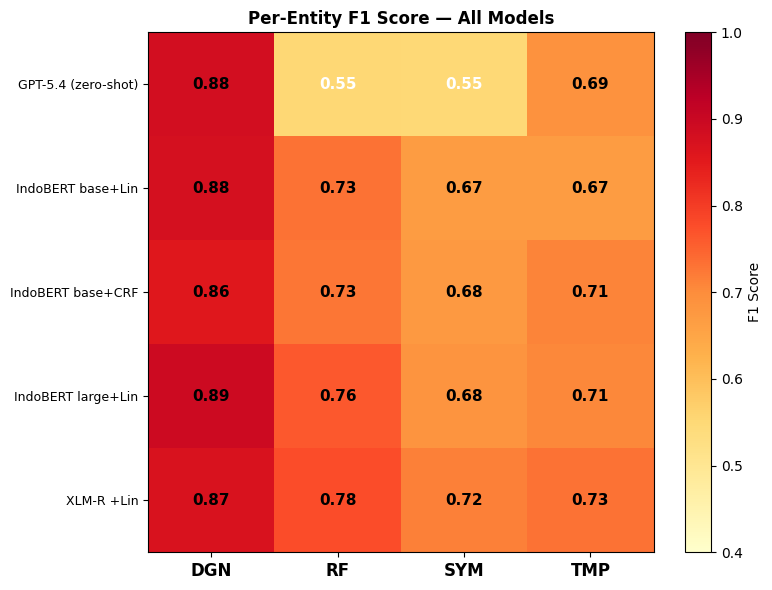

✅ Saved: per_entity_heatmap.png


In [ ]:
#Figure 2 Per-Entity F1 Heatmap
ENTITIES    = ['DGN', 'RF', 'SYM', 'TMP']
heatmap_row_labels = [
    SHORT_LABELS[m].replace('\n', ' ') for m in names_used
]

data = np.array([
    [all_results[m]['per_entity'].get(e, {}).get('f1', 0)
     for e in ENTITIES]
    for m in names_used
])

fig, ax = plt.subplots(figsize=(8, len(names_used) + 1))
im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=1.0)

ax.set_xticks(range(len(ENTITIES)))
ax.set_xticklabels(ENTITIES, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(names_used)))
ax.set_yticklabels(heatmap_row_labels, fontsize=9)

for i in range(len(names_used)):
    for j in range(len(ENTITIES)):
        v = data[i, j]
        ax.text(j, i, f'{v:.2f}',
                ha='center', va='center', fontsize=11,
                fontweight='bold',
                color='black' if v > 0.6 else 'white')

plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Entity F1 Score — All Models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('per_entity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_entity_heatmap.png')

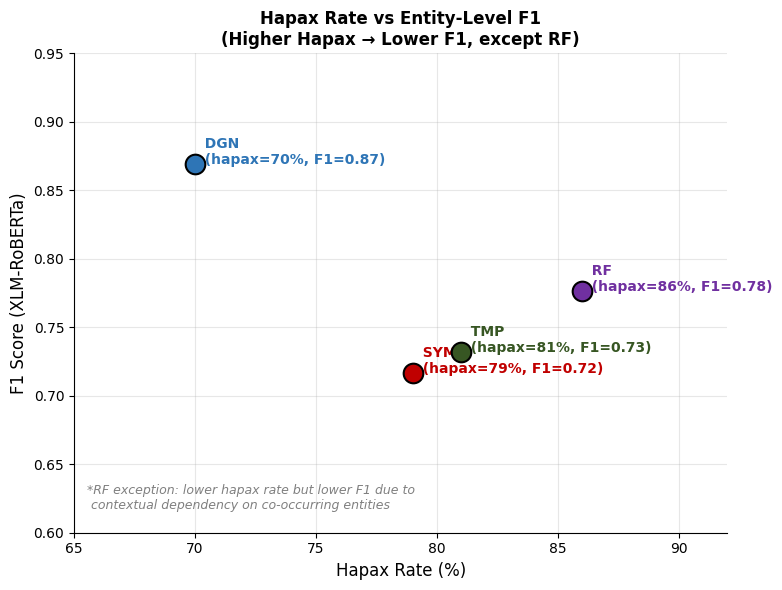

✅ Saved: hapax_vs_f1.png


In [ ]:
#Figure 3 Hapax Rate vs Entity F1 (Key Finding)
HAPAX_RATES = {'SYM': 79, 'DGN': 70, 'TMP': 81, 'RF': 86}
ENT_COLORS  = {'SYM': '#C00000', 'DGN': '#2E75B6', 'TMP': '#375623', 'RF': '#7030A0'}

xlm_key = 'XLM-RoBERTa + Linear'
if xlm_key in all_results:
    xlm_f1 = {e: all_results[xlm_key]['per_entity'].get(e, {}).get('f1', 0)
              for e in ['SYM', 'DGN', 'TMP', 'RF']}

    fig, ax = plt.subplots(figsize=(8, 6))
    for ent in ['DGN', 'RF', 'SYM', 'TMP']:
        ax.scatter(HAPAX_RATES[ent], xlm_f1[ent],
                   s=200, color=ENT_COLORS[ent],
                   zorder=5, edgecolors='black', lw=1.5)
        ax.annotate(
            f'  {ent}\n  (hapax={HAPAX_RATES[ent]}%, F1={xlm_f1[ent]:.2f})',
            (HAPAX_RATES[ent], xlm_f1[ent]),
            fontsize=10, fontweight='bold', color=ENT_COLORS[ent]
        )

    ax.set_xlabel('Hapax Rate (%)', fontsize=12)
    ax.set_ylabel('F1 Score (XLM-RoBERTa)', fontsize=12)
    ax.set_title('Hapax Rate vs Entity-Level F1\n(Higher Hapax → Lower F1, except RF)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(65, 92)
    ax.set_ylim(0.60, 0.95)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.annotate(
        '*RF exception: lower hapax rate but lower F1 due to\n'
        ' contextual dependency on co-occurring entities',
        xy=(0.02, 0.05), xycoords='axes fraction',
        fontsize=9, color='gray', style='italic'
    )
    plt.tight_layout()
    plt.savefig('hapax_vs_f1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: hapax_vs_f1.png')
else:
    print(f'  {xlm_key} not in results — skipping hapax plot')

In [ ]:
#Figure 4 training Curves All Fine-Tuned Models
SAVE_DIR = '/home/misel/stroke_ner/outputs/v2' # Assuming this is where sessionX_results.pkl are saved
session_map = [
    ('session1', 'IndoBERT-base + Linear'),
    ('session2', 'IndoBERT-base + CRF'),
    ('session3', 'IndoBERT-large + Linear'),
    ('session4', 'XLM-RoBERTa + Linear'),
]

histories = {}
for session, name in session_map:
    fpath = f'{SAVE_DIR}/{session}_results.pkl'
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            d = pickle.load(f)
        histories[name] = d.get('history', [])
    else:
        print(f'History not found for {name} ({fpath})')

if histories:
    MODEL_COLORS = {
        'IndoBERT-base + Linear':  '#C00000',
        'IndoBERT-base + CRF':     '#FF8C42',
        'IndoBERT-large + Linear': '#7030A0',
        'XLM-RoBERTa + Linear':    '#2E75B6',
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History — All Fine-Tuned Models (StrokeID-NER)',
                 fontsize=13, fontweight='bold')

    for name, hist in histories.items():
        c    = MODEL_COLORS.get(name, 'gray')
        eps  = [h['epoch']   for h in hist]
        loss = [h['loss']    for h in hist]
        vf1  = [h['val_f1']  for h in hist]
        axes[0].plot(eps, loss, 'o-', color=c, label=name, lw=2, markersize=5)
        axes[1].plot(eps, vf1,  'o-', color=c, label=name, lw=2, markersize=5)

    for ax, title, ylabel in [
        (axes[0], 'Training Loss',      'Loss'),
        (axes[1], 'Validation Macro F1', 'F1 Score')
    ]:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('all_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: all_training_curves.png')
else:
    print('No training histories found — skipping training curves plot')

⚠️  History not found for IndoBERT-base + Linear (/home/misel/stroke_ner/outputs/v2/session1_results.pkl)
⚠️  History not found for IndoBERT-base + CRF (/home/misel/stroke_ner/outputs/v2/session2_results.pkl)
⚠️  History not found for IndoBERT-large + Linear (/home/misel/stroke_ner/outputs/v2/session3_results.pkl)
⚠️  History not found for XLM-RoBERTa + Linear (/home/misel/stroke_ner/outputs/v2/session4_results.pkl)
⚠️  No training histories found — skipping training curves plot


In [ ]:
#Complete Results Table
print('COMPLETE RESULTS TABLE — StrokeID-NER (Test Set, n=275)')
print(f'{"Model":<34} {"Prec":>7} {"Rec":>7} {"F1":>7}  {"DGN":>6} {"RF":>6} {"SYM":>6} {"TMP":>6}')

best_f1    = max(all_results[m]['overall']['f1'] for m in names_used)
for name in MODELS_ORDER:
    if name not in all_results:
        continue
    o  = all_results[name]['overall']
    e  = all_results[name].get('per_entity', {})
    dgn = e.get('DGN', {}).get('f1', 0)
    rf  = e.get('RF',  {}).get('f1', 0)
    sym = e.get('SYM', {}).get('f1', 0)
    tmp = e.get('TMP', {}).get('f1', 0)
    marker = ' ← best' if abs(o['f1'] - best_f1) < 1e-6 else ''
    print(f'{name:<34} {o["prec"]:>7.4f} {o["rec"]:>7.4f} {o["f1"]:>7.4f}  '
          f'{dgn:>6.2f} {rf:>6.2f} {sym:>6.2f} {tmp:>6.2f}{marker}')

print(f'\nGPT model used: {GPT_MODEL}')
print('All fine-tuned models trained on train_fixed.tsv (1,211 sentences)')
print('Evaluation: seqeval span-level macro F1 on test_fixed.tsv (275 sentences)')


COMPLETE RESULTS TABLE — StrokeID-NER (Test Set, n=275)
Model                                 Prec     Rec      F1     DGN     RF    SYM    TMP
----------------------------------------------------------------------------------
GPT-5.4 (zero-shot)                 0.6762  0.6659  0.6682    0.88   0.55   0.55   0.69
IndoBERT-base + Linear              0.6976  0.7818  0.7367    0.88   0.73   0.67   0.67
IndoBERT-base + CRF                 0.7017  0.7896  0.7427    0.86   0.73   0.68   0.71
IndoBERT-large + Linear             0.7264  0.8004  0.7614    0.89   0.76   0.68   0.71
XLM-RoBERTa + Linear                0.7394  0.8125  0.7735    0.87   0.78   0.72   0.73 ← best

GPT model used: gpt-5.4
All fine-tuned models trained on train_fixed.tsv (1,211 sentences)
Evaluation: seqeval span-level macro F1 on test_fixed.tsv (275 sentences)


In [ ]:
#Save results to server
import os, shutil, pickle

SAVE_DIR = '/home/misel/stroke_ner/outputs/v2/gpt'
os.makedirs(SAVE_DIR, exist_ok=True)

# Complete results (all 5 models)
final_results = {
    k: {'overall': v['overall'], 'per_entity': v.get('per_entity', {})}
    for k, v in all_results.items()
}
with open(os.path.join(SAVE_DIR, 'complete_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

# GPT predictions and results
with open(os.path.join(SAVE_DIR, 'gpt_results.pkl'), 'wb') as f:
    pickle.dump({
        'model':      GPT_MODEL,
        'preds':      gpt_preds,
        'golds':      gpt_golds,
        'per_entity': per_gpt,
        'overall':    {'f1': gpt_f1, 'prec': gpt_prec, 'rec': gpt_rec}
    }, f)

# Figures
for fname in ['all_models_comparison.png', 'per_entity_heatmap.png',
              'hapax_vs_f1.png', 'all_training_curves.png']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))

print(f'All results and figures saved to: {SAVE_DIR}')
print(f'\nGPT-5.4 zero-shot: F1={gpt_f1:.4f}  P={gpt_prec:.4f}  R={gpt_rec:.4f}')
best_name = max(all_results, key=lambda m: all_results[m]['overall']['f1'])
best_f1v  = all_results[best_name]['overall']['f1']
print(f'Best fine-tuned:   {best_name} (F1={best_f1v:.4f})')
print(f'GPT vs best gap:   {best_f1v - gpt_f1:.4f} F1 points')


✅ All results and figures saved to: /home/misel/stroke_ner/outputs/v2/gpt

GPT-5.4 zero-shot: F1=0.6682  P=0.6762  R=0.6659
Best fine-tuned:   XLM-RoBERTa + Linear (F1=0.7735)
GPT vs best gap:   0.1053 F1 points
